In [2]:

import pandas as pd


In [3]:
df = pd.read_csv('/content/Salary_Data.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [5]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0


### Replace null values with mean for numerical columns and mode for categorical columns

In [6]:
import numpy as np

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

# Fill nulls in numerical columns with the mean
for col in numerical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Fill nulls in categorical columns with the mode
for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Null values after imputation:")
print(df.isnull().sum())

Null values after imputation:
YearsExperience    0
Salary             0
dtype: int64


### Apply Label Encoding to Categorical Columns

In [7]:
from sklearn.preprocessing import LabelEncoder

# Re-identify categorical columns as the previous code changed numerical_cols to string 'Salary'
categorical_cols = df.select_dtypes(include='object').columns

# Apply Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("DataFrame after Label Encoding:")
display(df.head())

DataFrame after Label Encoding:


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


Since there were no categorical columns (all columns were already numerical as seen in `df.info()`), the label encoding step doesn't change the DataFrame. However, the code provides a general solution for applying Label Encoding to `object` type columns if they were present.

### Separate Independent and Dependent Variables

In [8]:
# Separate the independent variable (X) and dependent variable (y)
X = df.iloc[:, :-1].values  # YearsExperience
y = df.iloc[:, -1].values   # Salary

print("Independent variable (X) head:")
print(X[:5])
print("\nDependent variable (y) head:")
print(y[:5])

Independent variable (X) head:
[[1.1]
 [1.3]
 [1.5]
 [2. ]
 [2.2]]

Dependent variable (y) head:
[39343. 46205. 37731. 43525. 39891.]


### Split the Data into Training and Test Sets

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (24, 1)
Shape of X_test: (6, 1)
Shape of y_train: (24,)
Shape of y_test: (6,)


### Train a Simple Linear Regression Model

In [10]:
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model
regressor_lr = LinearRegression()

# Train the model using the training sets
regressor_lr.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Train a Decision Tree Regression Model

In [11]:
from sklearn.tree import DecisionTreeRegressor

# Create a Decision Tree Regressor model
regressor_dt = DecisionTreeRegressor(random_state=0)

# Train the model
regressor_dt.fit(X_train, y_train)

print("Decision Tree Regression model trained successfully.")

Decision Tree Regression model trained successfully.


### Train a Random Forest Regression Model

In [12]:
from sklearn.ensemble import RandomForestRegressor

# Create a Random Forest Regressor model
regressor_rf = RandomForestRegressor(n_estimators=10, random_state=0)

# Train the model
regressor_rf.fit(X_train, y_train)

print("Random Forest Regression model trained successfully.")

Random Forest Regression model trained successfully.


### Train a Support Vector Machine (SVM) Regression Model

In [13]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Scale the data for SVM
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(len(y_train),1))

# Create an SVR model (using a radial basis function kernel as a common starting point)
regressor_svm = SVR(kernel='rbf')

# Train the model
regressor_svm.fit(X_train_scaled, y_train_scaled.ravel())

print("Support Vector Machine (SVM) Regression model trained successfully.")

Support Vector Machine (SVM) Regression model trained successfully.


### Train a K-Nearest Neighbors (KNN) Regression Model

In [14]:
from sklearn.neighbors import KNeighborsRegressor

# Create a KNN Regressor model
# n_neighbors=5 is a common starting point
regressor_knn = KNeighborsRegressor(n_neighbors=5)

# Train the model
regressor_knn.fit(X_train, y_train)

print("K-Nearest Neighbors (KNN) Regression model trained successfully.")

K-Nearest Neighbors (KNN) Regression model trained successfully.


### Visualize Linear Regression Results

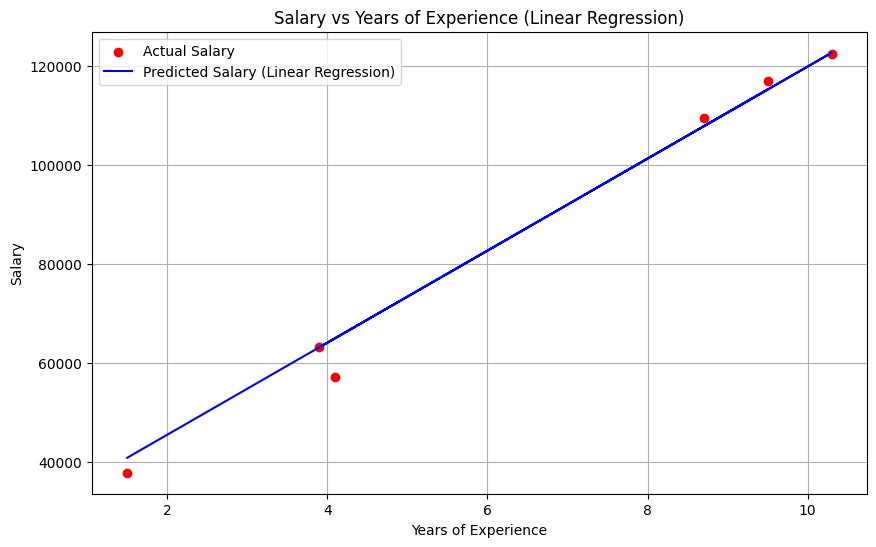

In [15]:
import matplotlib.pyplot as plt
import numpy as np

y_pred_lr = regressor_lr.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='red', label='Actual Salary')
plt.plot(X_test, y_pred_lr, color='blue', label='Predicted Salary (Linear Regression)')
plt.title('Salary vs Years of Experience (Linear Regression)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

### Visualize Decision Tree Regression Results

/tmp/ipykernel_1315/3345006762.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)


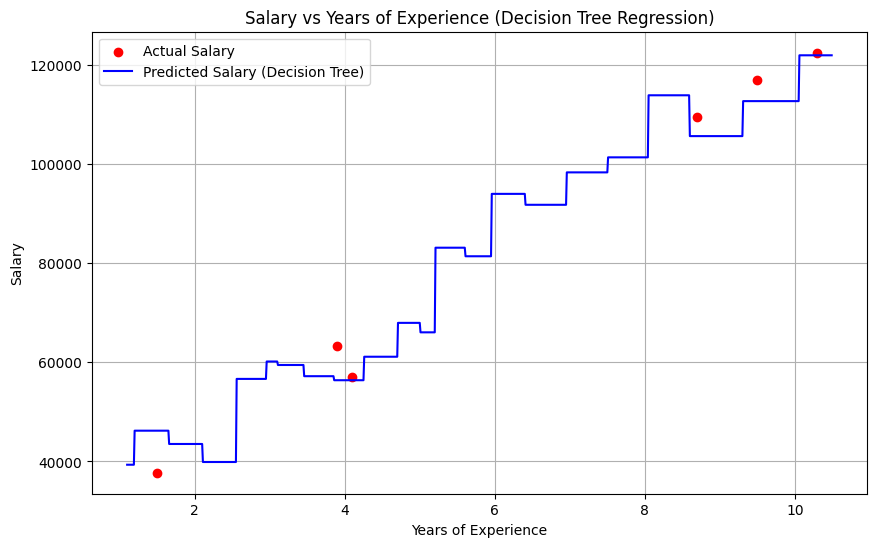

In [16]:
y_pred_dt = regressor_dt.predict(X_test)

# Create a range of values for a smoother curve for Decision Tree
X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='red', label='Actual Salary')
plt.plot(X_grid, regressor_dt.predict(X_grid), color='blue', label='Predicted Salary (Decision Tree)')
plt.title('Salary vs Years of Experience (Decision Tree Regression)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

### Visualize Random Forest Regression Results

/tmp/ipykernel_1315/1598747139.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)


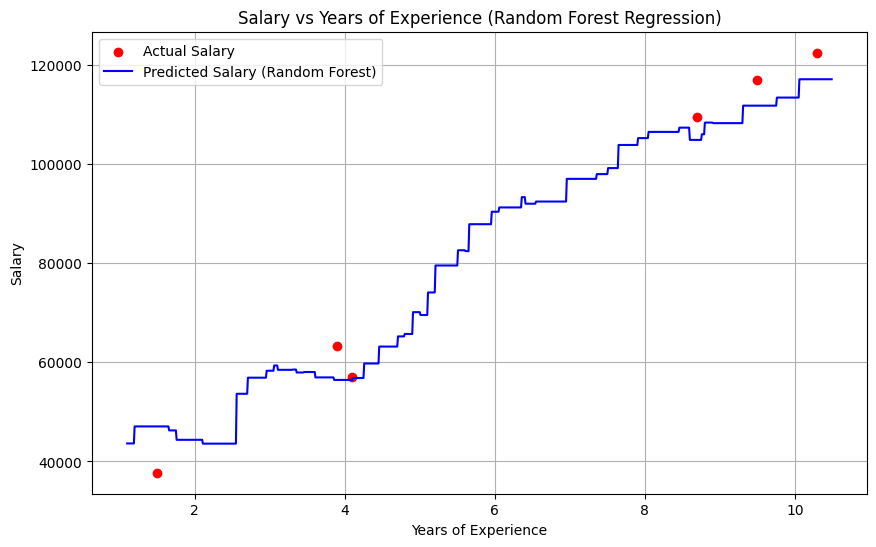

In [17]:
y_pred_rf = regressor_rf.predict(X_test)

# Create a range of values for a smoother curve for Random Forest
X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='red', label='Actual Salary')
plt.plot(X_grid, regressor_rf.predict(X_grid), color='blue', label='Predicted Salary (Random Forest)')
plt.title('Salary vs Years of Experience (Random Forest Regression)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

### Visualize Support Vector Machine (SVM) Regression Results

/tmp/ipykernel_1315/150123106.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid_svm = np.arange(min(X), max(X), 0.01).reshape(-1, 1)


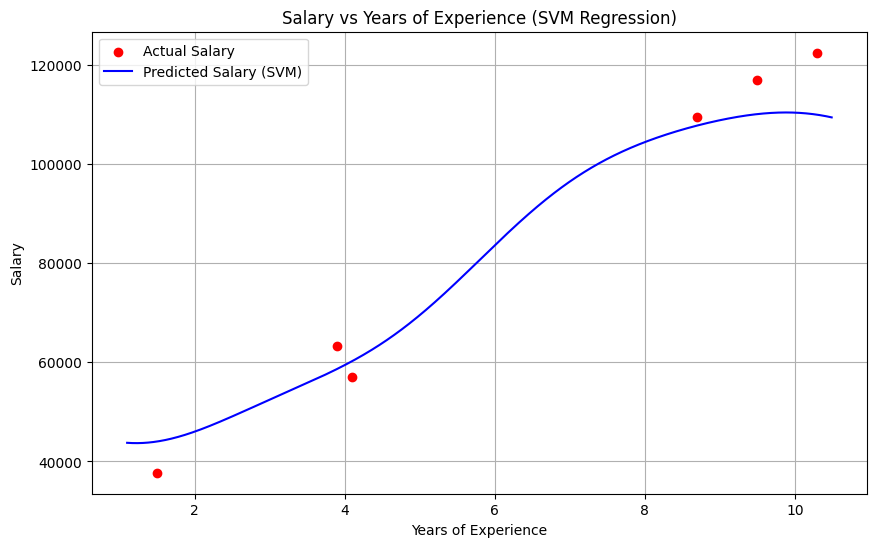

In [18]:
# Scale X_test for prediction with SVM
X_test_scaled = scaler_X.transform(X_test)

y_pred_svm_scaled = regressor_svm.predict(X_test_scaled)
y_pred_svm = scaler_y.inverse_transform(y_pred_svm_scaled.reshape(-1, 1))

# Prepare data for plotting the SVM curve
X_grid_svm = np.arange(min(X), max(X), 0.01).reshape(-1, 1)
X_grid_svm_scaled = scaler_X.transform(X_grid_svm)
y_grid_pred_svm_scaled = regressor_svm.predict(X_grid_svm_scaled)
y_grid_pred_svm = scaler_y.inverse_transform(y_grid_pred_svm_scaled.reshape(-1, 1))

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='red', label='Actual Salary')
plt.plot(X_grid_svm, y_grid_pred_svm, color='blue', label='Predicted Salary (SVM)')
plt.title('Salary vs Years of Experience (SVM Regression)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

### Visualize K-Nearest Neighbors (KNN) Regression Results

/tmp/ipykernel_1315/4122764973.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)


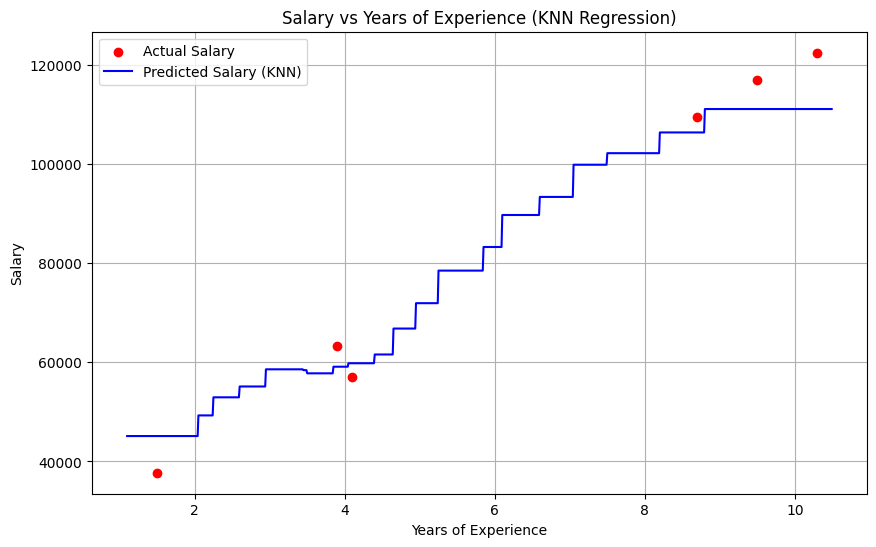

In [19]:
y_pred_knn = regressor_knn.predict(X_test)

# Create a range of values for a smoother curve for KNN
X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='red', label='Actual Salary')
plt.plot(X_grid, regressor_knn.predict(X_grid), color='blue', label='Predicted Salary (KNN)')
plt.title('Salary vs Years of Experience (KNN Regression)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

Now that all models have been trained and their predictions visualized, the next step would typically involve evaluating their performance using appropriate metrics (e.g., R-squared, MSE, MAE) on the test set, and then comparing them to select the best-performing model.

### Evaluate Model Performance

In [20]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd

def evaluate_model(model, X_test_data, y_test_data, model_name):
    if model_name == 'Support Vector Machine (SVM)':
        # SVM requires scaled data for prediction
        X_test_scaled_for_svm = scaler_X.transform(X_test_data)
        y_pred_scaled = model.predict(X_test_scaled_for_svm)
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
    else:
        y_pred = model.predict(X_test_data)

    r2 = r2_score(y_test_data, y_pred)
    mae = mean_absolute_error(y_test_data, y_pred)
    mse = mean_squared_error(y_test_data, y_pred)
    rmse = np.sqrt(mse)

    return {'Model': model_name, 'R2 Score': r2, 'MAE': mae, 'MSE': mse, 'RMSE': rmse}

# List to store results
results = []

# Evaluate Linear Regression
results.append(evaluate_model(regressor_lr, X_test, y_test, 'Linear Regression'))

# Evaluate Decision Tree
results.append(evaluate_model(regressor_dt, X_test, y_test, 'Decision Tree Regression'))

# Evaluate Random Forest
results.append(evaluate_model(regressor_rf, X_test, y_test, 'Random Forest Regression'))

# Evaluate SVM
results.append(evaluate_model(regressor_svm, X_test, y_test, 'Support Vector Machine (SVM)'))

# Evaluate KNN
results.append(evaluate_model(regressor_knn, X_test, y_test, 'K-Nearest Neighbors (KNN)'))

# Create a DataFrame from the results
performance_df = pd.DataFrame(results)

display(performance_df.round(2))

,Model,R2 Score,MAE,MSE,RMSE
0,Linear Regression,0.99,2446.17,12823412.30,3580.98
1,Decision Tree Regression,0.98,4120.67,25498988.42,5049.65
2,Random Forest Regression,0.97,5327.58,35151099.95,5928.84
3,Support Vector Machine (SVM),0.96,5860.88,46308267.11,6805.02
4,K-Nearest Neighbors (KNN),0.96,5769.13,42101903.75,6488.60


### Save Best Model

In [21]:
import pickle

# Assuming Linear Regression is the best model based on previous evaluation
best_model = regressor_lr

# Define the filename
filename = 'linear_regression_model.pkl'

# Save the model to disk
pickle.dump(best_model, open(filename, 'wb'))

print(f"Best model (Linear Regression) saved as '{filename}'")

Best model (Linear Regression) saved as 'linear_regression_model.pkl'


### Understanding the Metrics

Here's a brief explanation of the evaluation metrics used:

*   **R-squared ($R^2$)**: This metric represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R-squared of 1 indicates that the model explains all the variability of the response data around its mean, while an R-squared of 0 indicates that the model explains no variability. Higher values are generally better.

*   **Mean Absolute Error (MAE)**: This is the average of the absolute differences between predictions and actual observations. It measures the average magnitude of the errors in a set of predictions, without considering their direction. Lower MAE values indicate better model accuracy.

*   **Mean Squared Error (MSE)**: This is the average of the squares of the errors. It is useful because it more heavily penalizes large errors. Lower MSE values indicate better model accuracy.

*   **Root Mean Squared Error (RMSE)**: This is the square root of the MSE. It's often preferred in some contexts because it is in the same units as the dependent variable, making it more interpretable than MSE. Lower RMSE values indicate better model accuracy.

As observed from the output of `df.isnull().sum()`, there are currently no null values in the dataset, so the imputation step doesn't change the DataFrame. However, this code provides a general solution for handling nulls using mean/mode imputation for future use with datasets containing missing values.